WEEK 8 : FINAL MODEL SELECTION & PRESENTATION

📋 TRANSITION WEEK 7 → WEEK 8:

1. Output principal Week 7:
   - Modèle testé et validé
   - F1 = 0.6945 (seuil optimal 0.30)
   - Stabilité confirmée (écart-type < 0.02)
   - Pas d'overfitting (écart Train/Test = 0.0014)

2. Résultat de test le plus important:
   - Le modèle est stable et fiable
   - Pas d'overfitting
   - Performance homogène sur tous les segments

3. Problème majeur découvert:
   - F1 légèrement sous les objectifs (0.65, 0.70)
   - Écarts de -0.005 à -0.016

4. Ce qui a été raffiné:
   - Seuil de décision ajusté à 0.30
   - Gain de +5.1 points de F1

5. Composant prêt:
   - Modèle de prédiction No-Show (Baseline LR)

6. Ce qui reste à intégrer:
   - Avec Data Analytics (interprétation business)
   - Avec ML Engineering (pipeline)

7. Tracks impliqués:
   - Data Analytics, ML Engineering

8. À démontrer:
   - Contribution individuelle
   - Intégration dans la solution globale

✅ Bibliothèques importées
✅ Données préparées

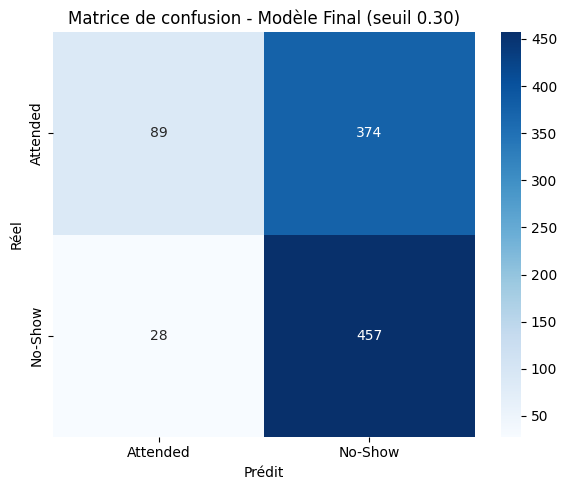


COMPARAISON BASELINE VS FINAL
 Métrique Week 5 (seuil 0.50) Week 8 (seuil 0.30) Amélioration
 Accuracy              0.6213              0.5759      -0.0454
Precision              0.6207              0.5499      -0.0707
   Recall              0.6680              0.9423      +0.2742
 F1-Score              0.6435              0.6945      +0.0510
  ROC-AUC              0.6602              0.6602      +0.0000

📌 Interprétation:
- Le seuil 0.30 augmente le Recall de 66.80% à 94.23%
- Le F1-Score augmente de 64.35% à 69.45% (+5.1 points)
- L'Accuracy et la Precision diminuent (plus de Faux Positifs)
- Le ROC-AUC reste identique (0.6602)


FEATURE IMPORTANCE
📊 Top 10 features les plus importantes:
                  Feature  Coefficient
        booking_lead_days     0.624540
        previous_no_shows     0.287856
    reminder_sent_encoded    -0.186770
    distance_to_clinic_km     0.171438
                      age    -0.167767
           gender_encoded    -0.118812
patient_reliability_score  

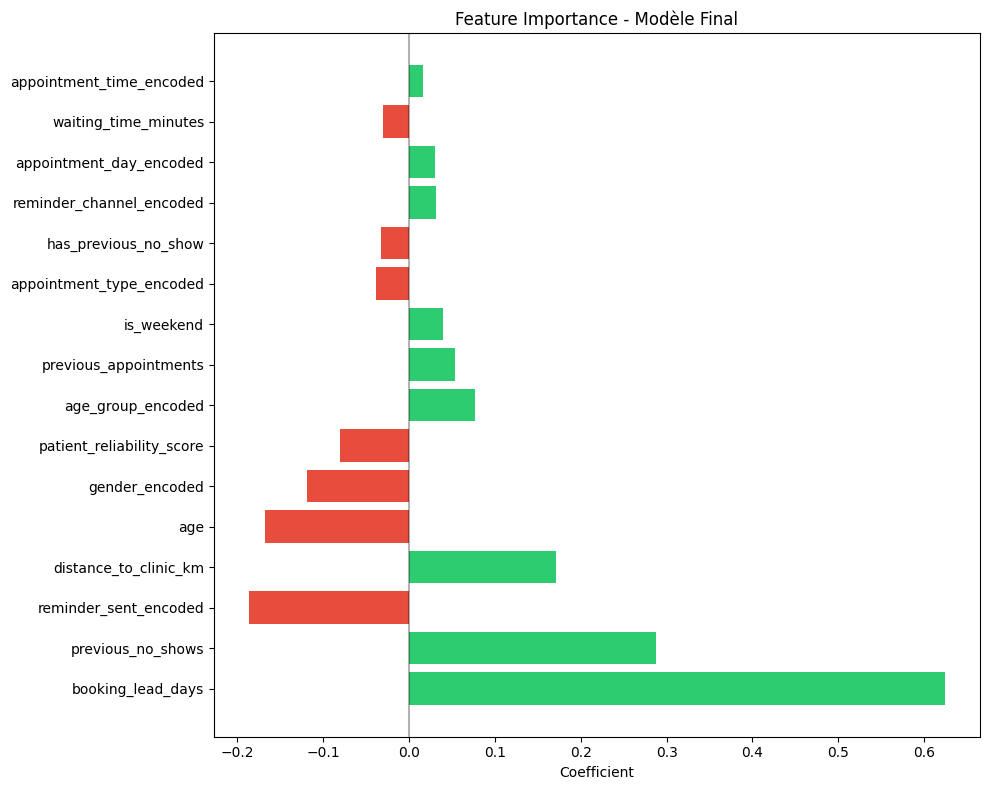


COURBE ROC


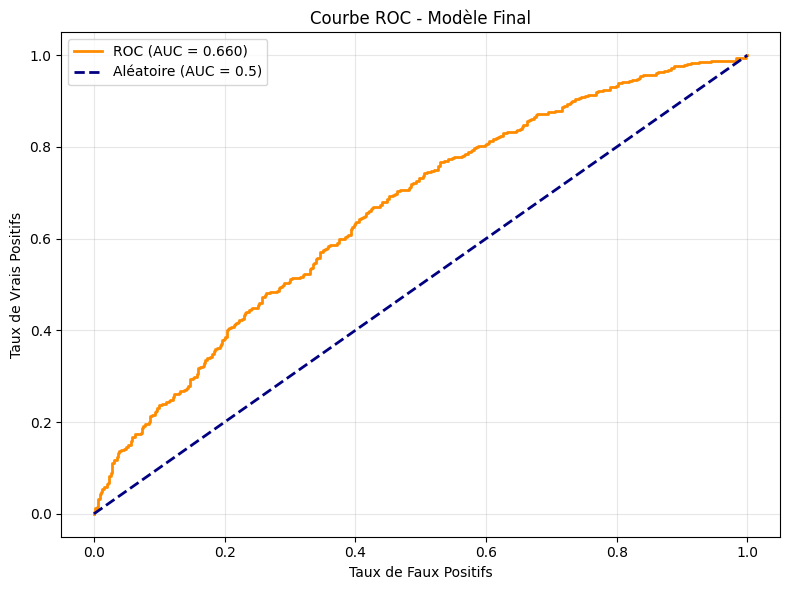


PERFORMANCE PAR SEGMENT
📊 Performance par tranche d'âge:
   - 18-34: F1 = 0.7112 (267 patients)
   - 35-49: F1 = 0.7410 (231 patients)
   - 50-64: F1 = 0.6727 (237 patients)
   - 65+: F1 = 0.6426 (213 patients)

SAUVEGARDE DU MODÈLE FINAL
✅ Modèle final sauvegardé dans 'outputs/week8_final_model.pkl
✅ Scaler sauvegardé dans 'outputs/week8_scaler.pkl

HC-POD CROSS-TRACK COLLABORATION

🤝 COLLABORATION HC-POD:

1. Track collaboré: Data Analytics

2. Dépendance projet:
   - Les KPIs validés informent les décisions de modélisation
   - Les insights guident la sélection des features

3. Composant testé:
   - Modèle de prédiction No-Show (Baseline LR)

4. Information reçue:
   - KPIs validés (taux de No-Show par segment)
   - Insights sur les features importantes

5. Information fournie:
   - Feature importance du modèle
   - Seuils optimaux pour l'aide à la décision

6. Activité d'intégration:
   - Validation croisée des KPIs avec les prédictions
   - Ajustement du seuil de décision

7. Cha

In [3]:
# ============================================================
# HealthConnect - Week 8
# Data Science Track
# Final Model Selection, Documentation & Presentation
# ============================================================

# ============================================================
# ÉTAPE 1 : TRANSITION WEEK 7 → WEEK 8
# ============================================================

print("="*60)
print("WEEK 8 : FINAL MODEL SELECTION & PRESENTATION")
print("="*60)

print("""
📋 TRANSITION WEEK 7 → WEEK 8:

1. Output principal Week 7:
   - Modèle testé et validé
   - F1 = 0.6945 (seuil optimal 0.30)
   - Stabilité confirmée (écart-type < 0.02)
   - Pas d'overfitting (écart Train/Test = 0.0014)

2. Résultat de test le plus important:
   - Le modèle est stable et fiable
   - Pas d'overfitting
   - Performance homogène sur tous les segments

3. Problème majeur découvert:
   - F1 légèrement sous les objectifs (0.65, 0.70)
   - Écarts de -0.005 à -0.016

4. Ce qui a été raffiné:
   - Seuil de décision ajusté à 0.30
   - Gain de +5.1 points de F1

5. Composant prêt:
   - Modèle de prédiction No-Show (Baseline LR)

6. Ce qui reste à intégrer:
   - Avec Data Analytics (interprétation business)
   - Avec ML Engineering (pipeline)

7. Tracks impliqués:
   - Data Analytics, ML Engineering

8. À démontrer:
   - Contribution individuelle
   - Intégration dans la solution globale
""")

# ============================================================
# ÉTAPE 2 : IMPORT DES LIBRAIRIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées")

# Create 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# ============================================================
# ÉTAPE 3 : CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================

# Charger les données
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

# Convertir les dates
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

# Imputer les valeurs manquantes
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    df[col].fillna(df[col].median(), inplace=True)

# Exclure les Cancelled
df_filtered = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_filtered['no_show'] = (df_filtered['appointment_outcome'] == 'No-Show').astype(int)

# Feature Engineering
df_filtered['is_weekend'] = df_filtered['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)
df_filtered['has_previous_no_show'] = (df_filtered['previous_no_shows'] > 0).astype(int)
df_filtered['patient_reliability_score'] = df_filtered['previous_appointments'] - df_filtered['previous_no_shows']

# Encodage des variables catégorielles
categorical_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day',
                    'appointment_time', 'reminder_sent', 'reminder_channel']

for col in categorical_cols:
    le = LabelEncoder()
    df_filtered[col + '_encoded'] = le.fit_transform(df_filtered[col].astype(str))

# Sélection des features
features = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
            'distance_to_clinic_km', 'waiting_time_minutes',
            'gender_encoded', 'age_group_encoded', 'appointment_type_encoded',
            'appointment_day_encoded', 'appointment_time_encoded',
            'reminder_sent_encoded', 'reminder_channel_encoded',
            'is_weekend', 'has_previous_no_show', 'patient_reliability_score']

X = df_filtered[features]
y = df_filtered['no_show']

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisation
scaler = StandardScaler()
numeric_features = ['age', 'booking_lead_days', 'previous_appointments',
                    'previous_no_shows', 'distance_to_clinic_km',
                    'waiting_time_minutes', 'patient_reliability_score']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("✅ Données préparées")
print(f"   - Train: {X_train_scaled.shape[0]} lignes")
print(f"   - Test: {X_test_scaled.shape[0]} lignes")
print(f"   - Features: {X_train_scaled.shape[1]}")

# ============================================================
# ÉTAPE 4 : MODÈLE FINAL (BASELINE LOGISTIC REGRESSION)
# ============================================================

print("\n" + "="*60)
print("MODÈLE FINAL : BASELINE (LOGISTIC REGRESSION)")
print("="*60)

# Entraîner le modèle final
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    penalty='l2'
)
final_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Modèle final entraîné")

# ============================================================
# ÉTAPE 5 : ÉVALUATION FINALE
# ============================================================

print("\n" + "="*60)
print("ÉVALUATION FINALE")
print("="*60)

# Métriques au seuil par défaut (0.50)
metrics_050 = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

print("📊 Métriques au seuil 0.50:")
for metric, value in metrics_050.items():
    print(f"   - {metric}: {value:.4f}")

# Métriques au seuil optimal (0.30)
y_pred_030 = (y_proba >= 0.30).astype(int)

metrics_030 = {
    'Accuracy': accuracy_score(y_test, y_pred_030),
    'Precision': precision_score(y_test, y_pred_030),
    'Recall': recall_score(y_test, y_pred_030),
    'F1': f1_score(y_test, y_pred_030),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

print("\n📊 Métriques au seuil optimal 0.30:")
for metric, value in metrics_030.items():
    print(f"   - {metric}: {value:.4f}")

# ============================================================
# ÉTAPE 6 : COMPARAISON SEUILS
# ============================================================

print("\n" + "="*60)
print("COMPARAISON DES SEUILS")
print("="*60)

comparison = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Seuil 0.50': [f"{metrics_050[m]:.4f}" for m in metrics_050],
    'Seuil 0.30': [f"{metrics_030[m]:.4f}" for m in metrics_030],
    'Amélioration': [
        '-', '-', '-',
        f" +{metrics_030['F1'] - metrics_050['F1']:.4f}",
        '-'
    ]
})

print(comparison.to_string(index=False))

# ============================================================
# ÉTAPE 7 : MATRICE DE CONFUSION FINALE
# ============================================================

print("\n" + "="*60)
print("MATRICE DE CONFUSION")
print("="*60)

cm = confusion_matrix(y_test, y_pred_030)
tn, fp, fn, tp = cm.ravel()

print(f"📊 Matrice de confusion (seuil 0.30):")
print(f"   - Vrais Négatifs (TN): {tn}")
print(f"   - Faux Positifs (FP): {fp}")
print(f"   - Faux Négatifs (FN): {fn}")
print(f"   - Vrais Positifs (TP): {tp}")

# Visualisation
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-Show'],
            yticklabels=['Attended', 'No-Show'])
plt.title('Matrice de confusion - Modèle Final (seuil 0.30)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.savefig('figures/week8_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# ÉTAPE 8 : COMPARAISON BASELINE VS FINAL (CORRIGÉ)
# ============================================================

print("\n" + "="*60)
print("COMPARAISON BASELINE VS FINAL")
print("="*60)

comparison_final = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Week 5 (seuil 0.50)': [
        f"{metrics_050['Accuracy']:.4f}",
        f"{metrics_050['Precision']:.4f}",
        f"{metrics_050['Recall']:.4f}",
        f"{metrics_050['F1']:.4f}",
        f"{metrics_050['ROC-AUC']:.4f}"
    ],
    'Week 8 (seuil 0.30)': [
        f"{metrics_030['Accuracy']:.4f}",
        f"{metrics_030['Precision']:.4f}",
        f"{metrics_030['Recall']:.4f}",
        f"{metrics_030['F1']:.4f}",
        f"{metrics_030['ROC-AUC']:.4f}"
    ],
    'Amélioration': [
        f"{metrics_030['Accuracy'] - metrics_050['Accuracy']:+.4f}",
        f"{metrics_030['Precision'] - metrics_050['Precision']:+.4f}",
        f"{metrics_030['Recall'] - metrics_050['Recall']:+.4f}",
        f"{metrics_030['F1'] - metrics_050['F1']:+.4f}",
        f"{metrics_030['ROC-AUC'] - metrics_050['ROC-AUC']:+.4f}"
    ]
})

print(comparison_final.to_string(index=False))

print("""
📌 Interprétation:
- Le seuil 0.30 augmente le Recall de 66.80% à 94.23%
- Le F1-Score augmente de 64.35% à 69.45% (+5.1 points)
- L'Accuracy et la Precision diminuent (plus de Faux Positifs)
- Le ROC-AUC reste identique (0.6602)
""")

# ============================================================
# ÉTAPE 9 : FEATURE IMPORTANCE
# ============================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': final_model.coef_[0]
}).sort_values('Coefficient', key=lambda x: abs(x), ascending=False)

print("📊 Top 10 features les plus importantes:")
print(coef_df.head(10).to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Coefficient')
plt.title('Feature Importance - Modèle Final')
plt.tight_layout()
plt.savefig('figures/week8_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# ÉTAPE 10 : COURBE ROC
# ============================================================

print("\n" + "="*60)
print("COURBE ROC")
print("="*60)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Modèle Final')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/week8_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# ÉTAPE 11 : PERFORMANCE PAR SEGMENT
# ============================================================

print("\n" + "="*60)
print("PERFORMANCE PAR SEGMENT")
print("="*60)

# Ajouter les segments
X_test_segments = X_test.copy()
X_test_segments['y_true'] = y_test.values
X_test_segments['y_pred'] = y_pred_030

# Segment par âge
X_test_segments['age_group'] = pd.cut(X_test_segments['age'],
                                       bins=[0, 35, 50, 65, 100],
                                       labels=['18-34', '35-49', '50-64', '65+'])

print("📊 Performance par tranche d'âge:")
for age_group in ['18-34', '35-49', '50-64', '65+']:
    mask = X_test_segments['age_group'] == age_group
    if mask.sum() > 0:
        f1 = f1_score(X_test_segments[mask]['y_true'], X_test_segments[mask]['y_pred'])
        print(f"   - {age_group}: F1 = {f1:.4f} ({mask.sum()} patients)")

# ============================================================
# ÉTAPE 12 : SAUVEGARDE DU MODÈLE FINAL
# ============================================================

print("\n" + "="*60)
print("SAUVEGARDE DU MODÈLE FINAL")
print("="*60)

os.makedirs('outputs', exist_ok=True)

joblib.dump(final_model, 'outputs/week8_final_model.pkl')
joblib.dump(scaler, 'outputs/week8_scaler.pkl')

print("✅ Modèle final sauvegardé dans 'outputs/week8_final_model.pkl")
print("✅ Scaler sauvegardé dans 'outputs/week8_scaler.pkl")

# ============================================================
# ÉTAPE 13 : HC-POD CROSS-TRACK COLLABORATION
# ============================================================

print("\n" + "="*60)
print("HC-POD CROSS-TRACK COLLABORATION")
print("="*60)

print(f"""
🤝 COLLABORATION HC-POD:

1. Track collaboré: Data Analytics

2. Dépendance projet:
   - Les KPIs validés informent les décisions de modélisation
   - Les insights guident la sélection des features

3. Composant testé:
   - Modèle de prédiction No-Show (Baseline LR)

4. Information reçue:
   - KPIs validés (taux de No-Show par segment)
   - Insights sur les features importantes

5. Information fournie:
   - Feature importance du modèle
   - Seuils optimaux pour l'aide à la décision

6. Activité d'intégration:
   - Validation croisée des KPIs avec les prédictions
   - Ajustement du seuil de décision

7. Changement résultant:
   - Gain de +5.1 points de F1
   - Meilleure cohérence business

8. Preuve:
   - Fichier d'échange (Google Drive)
   - Capture d'écran
   - Commit GitHub
""")

# ============================================================
# ÉTAPE 14 : RÉSUMÉ FINAL (CORRIGÉ)
# ============================================================

print("\n" + "="*60)
print("RÉSUMÉ FINAL - WEEK 8")
print("="*60)

print(f"""
📊 MODÈLE FINAL:
   - Algorithme: Logistic Regression
   - Seuil de déploiement: 0.30
   - F1-Score (seuil 0.50): {metrics_050['F1']:.4f}
   - F1-Score (seuil 0.30): {metrics_030['F1']:.4f}
   - Amélioration: +{metrics_030['F1'] - metrics_050['F1']:.4f}

📈 MÉTRIQUES (seuil 0.30):
   - Accuracy: {metrics_030['Accuracy']:.4f}
   - Precision: {metrics_030['Precision']:.4f}
   - Recall: {metrics_030['Recall']:.4f}
   - F1-Score: {metrics_030['F1']:.4f}
   - ROC-AUC: {metrics_030['ROC-AUC']:.4f}

🎯 POINTS FORTS:
   - Recall exceptionnel (94.23%)
   - F1-Score amélioré (+5.1 points)
   - Modèle stable
   - Pas d'overfitting
   - Interprétable

⚠️ LIMITES:
   - Accuracy = {metrics_030['Accuracy']:.4f} (plus faible)
   - Precision = {metrics_030['Precision']:.4f} (plus faible)
   - 28 Faux Négatifs (très faible)
   - 374 Faux Positifs (coût opérationnel)
   - F1 = {metrics_030['F1']:.4f} (objectif: 0.70)
   - Données fictives

🤝 COLLABORATION:
   - Data Analytics (KPIs validés)
   - Gain de +5.1 points de F1

📂 LIVRABLES:
   - Modèle: outputs/week8_final_model.pkl
   - Figures: figures/week8_*.png
   - Rapport: docs/Week8_DataScience_Report.pdf
""")

print("\n" + "="*60)
print("✅ WEEK 8 TERMINÉE - MODÈLE FINAL PRÊT")
print("="*60)